In [1]:
import sys, os

ML_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
SRC_DIR = os.path.join(ML_ROOT, "src")
sys.path.insert(0, ML_ROOT)
sys.path.insert(0, SRC_DIR)

import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report, confusion_matrix,
    top_k_accuracy_score, f1_score
)
import config
from model import build_model
from dataset import DermaSenseDataset
from utils import set_seed

set_seed(config.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
PROC = config.DATA_PROCESSED

val_df  = pd.read_csv(os.path.join(PROC, "val.csv"))
test_df = pd.read_csv(os.path.join(PROC, "test.csv"))

with open(os.path.join(PROC, "label2idx.json")) as f:
    l2i = json.load(f)
with open(os.path.join(PROC, "idx2label.json")) as f:
    i2l = {int(k): v for k, v in json.load(f).items()}

config.NUM_CLASSES = len(l2i)

# Load best model
net = build_model(
    num_classes = config.NUM_CLASSES,
    tabular_dim = config.TABULAR_DIM,
    fusion_dim  = config.FUSION_DIM,
    dropout     = config.DROPOUT,
    pretrained  = False,
).to(device)

ckpt = torch.load(config.BEST_MODEL, map_location=device)
net.load_state_dict(ckpt["model_state"])
net.eval()

print(f"✅ Loaded checkpoint — Epoch {ckpt['epoch']} | Best Val Acc: {ckpt['best_val_acc']:.4f}")
print(f"Classes: {config.NUM_CLASSES}")

C:\Users\LOQ\AppData\Local\Temp\ipykernel_20988\368054148.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(config.BEST_MODEL, map_location=device)


✅ Loaded checkpoint — Epoch 32 | Best Val Acc: 0.6390
Classes: 181


In [3]:
EXTRA_DIRS = [config.DATASET_DIR_0, config.DATASET_DIR_1]

def get_predictions(df, label2idx, train=False):
    ds = DermaSenseDataset(
        df, config.DATASET_DIR_0, label2idx,
        config.IMG_COL, config.LABEL_COL,
        config.IMG_SIZE, train=train,
        extra_dirs=EXTRA_DIRS
    )
    loader = DataLoader(ds, batch_size=32, shuffle=False,
                        num_workers=0, pin_memory=False)

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, tabs, labels in loader:
            imgs   = imgs.to(device)
            tabs   = tabs.to(device)
            logits = net(imgs, tabs)
            probs  = torch.softmax(logits, dim=1)

            all_preds.append(logits.argmax(dim=1).cpu().numpy())
            all_labels.append(labels.numpy())
            all_probs.append(probs.cpu().numpy())

    return (
        np.concatenate(all_preds),
        np.concatenate(all_labels),
        np.concatenate(all_probs)
    )

print("Running val inference...")
val_preds, val_labels, val_probs = get_predictions(val_df, l2i)
print(f"✅ Val inference done — {len(val_preds)} samples")

Running val inference...
✅ Val inference done — 653 samples


In [4]:
top1 = (val_preds == val_labels).mean()

# labels parameter explicitly pass karo — all 181 classes
all_labels_list = list(range(config.NUM_CLASSES))

top5 = top_k_accuracy_score(val_labels, val_probs, k=5, labels=all_labels_list)
top3 = top_k_accuracy_score(val_labels, val_probs, k=3, labels=all_labels_list)
macro_f1    = f1_score(val_labels, val_preds, average="macro",    zero_division=0)
weighted_f1 = f1_score(val_labels, val_preds, average="weighted", zero_division=0)

print("="*45)
print("  VALIDATION METRICS")
print("="*45)
print(f"  Top-1 Accuracy  : {top1:.4f}  ({top1*100:.2f}%)")
print(f"  Top-3 Accuracy  : {top3:.4f}  ({top3*100:.2f}%)")
print(f"  Top-5 Accuracy  : {top5:.4f}  ({top5*100:.2f}%)")
print(f"  Macro F1        : {macro_f1:.4f}")
print(f"  Weighted F1     : {weighted_f1:.4f}")
print("="*45)

  VALIDATION METRICS
  Top-1 Accuracy  : 0.6401  (64.01%)
  Top-3 Accuracy  : 0.8132  (81.32%)
  Top-5 Accuracy  : 0.8652  (86.52%)
  Macro F1        : 0.4352
  Weighted F1     : 0.6074


In [5]:
# Val mein jo classes actually present hain unke indices
present_classes = sorted(np.unique(val_labels).tolist())
present_names   = [i2l[i] for i in present_classes]

report = classification_report(
    val_labels, val_preds,
    labels      = present_classes,
    target_names= present_names,
    output_dict = True,
    zero_division = 0
)
report_df = pd.DataFrame(report).T.iloc[:-3]
report_df = report_df.sort_values("f1-score", ascending=False)

print("── Top 15 Classes (highest F1) ──")
print(report_df.head(15)[["precision","recall","f1-score","support"]].to_string())

print("\n── Bottom 15 Classes (lowest F1) ──")
print(report_df.tail(15)[["precision","recall","f1-score","support"]].to_string())

report_df.to_csv(os.path.join(config.PLOTS_DIR, "per_class_report.csv"))
print("\n✅ per_class_report.csv saved")

── Top 15 Classes (highest F1) ──
                                      precision  recall  f1-score  support
Dryness (xerosis)                           1.0     1.0       1.0      1.0
Epidermolysis Bullosa Simplex               1.0     1.0       1.0      1.0
Folliculitis Decalvans                      1.0     1.0       1.0      1.0
Chronic Bullous Disease of Childhood        1.0     1.0       1.0      1.0
Chromoblastomycosis                         1.0     1.0       1.0      1.0
Basal Cell Carcinoma                        1.0     1.0       1.0      1.0
Varicella Zoster                            1.0     1.0       1.0      1.0
Psoriasis Vulgaris                          1.0     1.0       1.0      1.0
Scleroderma                                 1.0     1.0       1.0      1.0
Sebaceous Cyst                              1.0     1.0       1.0      1.0
Pityriasis lichenoides chronica             1.0     1.0       1.0      1.0
Verruca Vulgaris                            1.0     1.0       1.0 

Samples in top-20 confusion matrix: 367


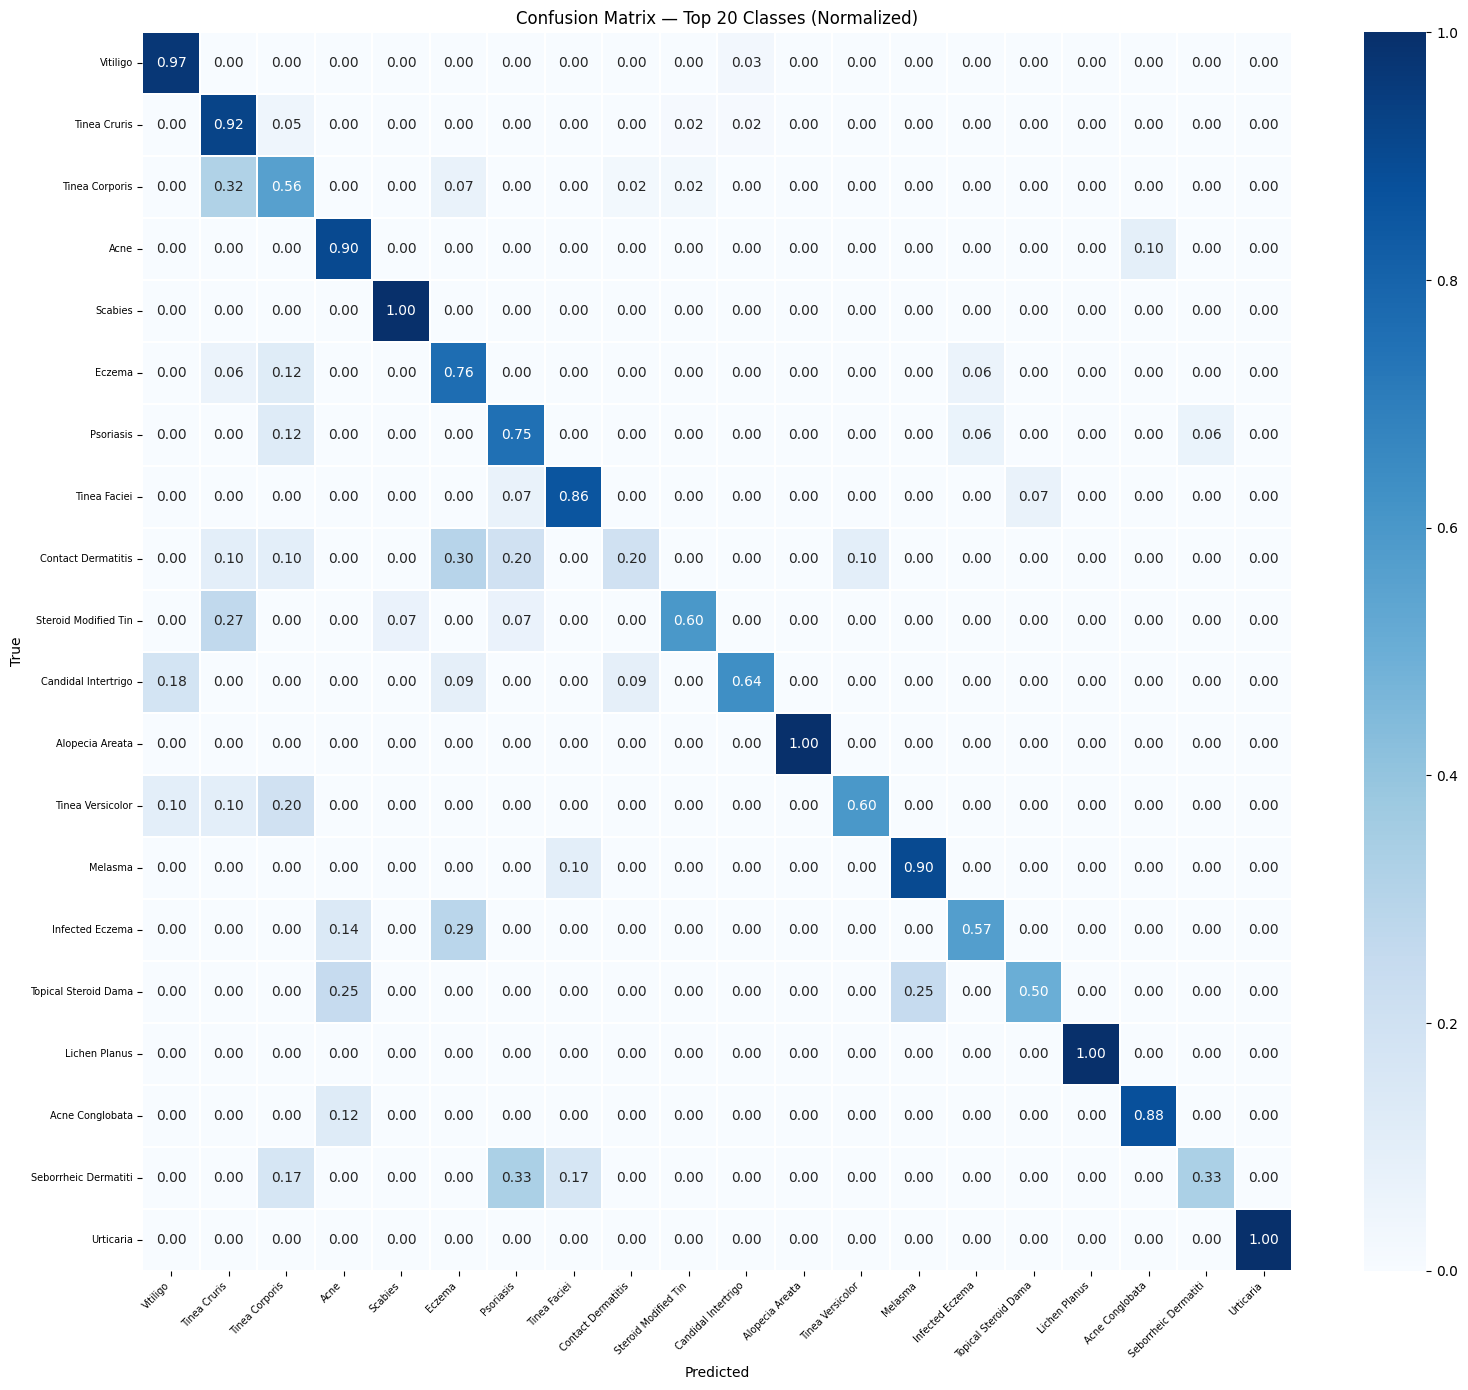

In [7]:
top20_idx = report_df.sort_values("support", ascending=False).head(20).index.tolist()
top20_int = [l2i[n] for n in top20_idx if n in l2i]
top20_set = set(top20_int)

# Sirf woh rows rakhni hain jahan DONO — true label aur prediction — top20 mein hain
mask_val   = np.isin(val_labels, top20_int) & np.isin(val_preds, top20_int)
sub_labels = val_labels[mask_val]
sub_preds  = val_preds[mask_val]

print(f"Samples in top-20 confusion matrix: {mask_val.sum()}")

remap        = {old: new for new, old in enumerate(top20_int)}
sub_labels_r = np.array([remap[x] for x in sub_labels])
sub_preds_r  = np.array([remap[x] for x in sub_preds])
class_names  = [i2l[i][:20] for i in top20_int]

cm      = confusion_matrix(sub_labels_r, sub_preds_r, labels=list(range(20)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, linewidths=0.3)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Top 20 Classes (Normalized)")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(f"{config.PLOTS_DIR}/confusion_matrix.png", dpi=150)
plt.show()

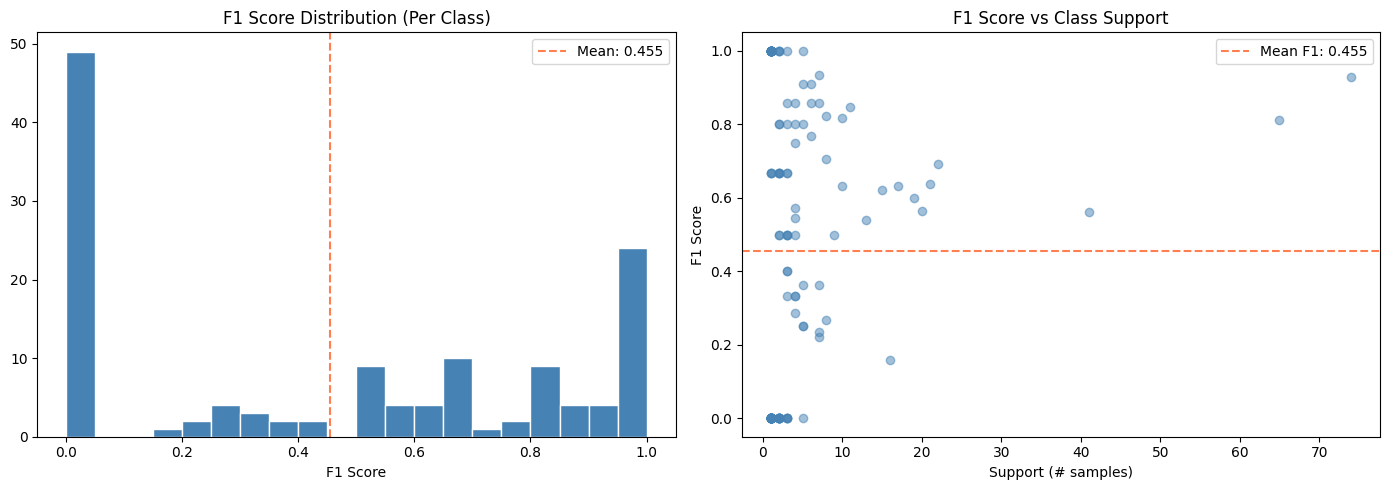

Classes with F1 = 0.0 : 49
Classes with F1 > 0.5 : 64
Classes with F1 > 0.7 : 44


In [8]:
f1_scores = report_df["f1-score"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(f1_scores, bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(f1_scores.mean(), color="coral", linestyle="--",
                label=f"Mean: {f1_scores.mean():.3f}")
axes[0].set_title("F1 Score Distribution (Per Class)")
axes[0].set_xlabel("F1 Score"); axes[0].legend()

# F1 vs Support scatter
support = report_df["support"].astype(float)
axes[1].scatter(support, f1_scores, alpha=0.5, color="steelblue")
axes[1].set_xlabel("Support (# samples)"); axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 Score vs Class Support")
axes[1].axhline(f1_scores.mean(), color="coral", linestyle="--",
                label=f"Mean F1: {f1_scores.mean():.3f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{config.PLOTS_DIR}/f1_distribution.png", dpi=150)
plt.show()

print(f"Classes with F1 = 0.0 : {(f1_scores == 0).sum()}")
print(f"Classes with F1 > 0.5 : {(f1_scores > 0.5).sum()}")
print(f"Classes with F1 > 0.7 : {(f1_scores > 0.7).sum()}")

In [10]:
with open(os.path.join(PROC, "rare_classes.json")) as f:
    rare = json.load(f)

test_filtered = test_df[~test_df[config.LABEL_COL].isin(rare)].copy()
test_filtered = test_filtered[test_filtered[config.LABEL_COL].isin(l2i.keys())].copy()
print(f"Test original : {len(test_df)} | After filter: {len(test_filtered)}")

print("Running test inference...")
test_preds, test_labels, test_probs = get_predictions(test_filtered, l2i)

all_labels_list = list(range(config.NUM_CLASSES))

t1  = (test_preds == test_labels).mean()
t5  = top_k_accuracy_score(test_labels, test_probs, k=5, labels=all_labels_list)
t3  = top_k_accuracy_score(test_labels, test_probs, k=3, labels=all_labels_list)
mf1 = f1_score(test_labels, test_preds, average="macro",    zero_division=0)
wf1 = f1_score(test_labels, test_preds, average="weighted", zero_division=0)

print("\n" + "="*45)
print("  TEST SET FINAL METRICS")
print("="*45)
print(f"  Top-1 Accuracy  : {t1:.4f}  ({t1*100:.2f}%)")
print(f"  Top-3 Accuracy  : {t3:.4f}  ({t3*100:.2f}%)")
print(f"  Top-5 Accuracy  : {t5:.4f}  ({t5*100:.2f}%)")
print(f"  Macro F1        : {mf1:.4f}")
print(f"  Weighted F1     : {wf1:.4f}")
print("="*45)

Test original : 1051 | After filter: 1019
Running test inference...

  TEST SET FINAL METRICS
  Top-1 Accuracy  : 0.4985  (49.85%)
  Top-3 Accuracy  : 0.6555  (65.55%)
  Top-5 Accuracy  : 0.7134  (71.34%)
  Macro F1        : 0.2107
  Weighted F1     : 0.4631
